# Baseline + BERT Fine-tuning

Acest notebook:
1. Rulează baseline-ul TF-IDF + Logistic Regression
2. Fine-tuning DistilBERT pe e-mailurile sintetice
3. Compară rezultatele


In [2]:
# 1. Install dependencies
!pip install -q transformers datasets accelerate scikit-learn

In [3]:
# 2. Upload dataset files
# Upload: train.csv, val.csv, test.csv=
from google.colab import files
uploaded = files.upload()
print(f"Uploaded: {list(uploaded.keys())}")

Saving test.csv to test (1).csv
Saving train.csv to train (1).csv
Saving val.csv to val (1).csv
Uploaded: ['test (1).csv', 'train (1).csv', 'val (1).csv']


In [4]:
# 3. Configuration
import csv
import json
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

INTENT_LABELS = [
    "invoice_submission",
    "other",
    "price_increase",
    "price_validity_confirmation",
    "quote_offer",
]
LABEL2ID = {label: i for i, label in enumerate(INTENT_LABELS)}
ID2LABEL = {i: label for label, i in LABEL2ID.items()}

def load_split(filepath):
    texts, labels = [], []
    with open(filepath, 'r', encoding='utf-8') as f:
        for row in csv.DictReader(f):
            text = f"Subject: {row.get('subject', '')}\n\n{row.get('body', '')}"
            texts.append(text)
            labels.append(LABEL2ID[row['intent']])
    return texts, labels

train_texts, train_labels = load_split('train.csv')
val_texts, val_labels = load_split('val.csv')
test_texts, test_labels = load_split('test.csv')
print(f'Train: {len(train_texts)}, Val: {len(val_texts)}, Test: {len(test_texts)}')

Train: 345, Val: 69, Test: 86


In [5]:
# 4. BASELINE — TF-IDF + Logistic Regression
baseline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1, 2), sublinear_tf=True)),
    ('clf', LogisticRegression(max_iter=1000, C=1.0, class_weight='balanced', random_state=42)),
])
baseline.fit(train_texts, train_labels)

baseline_preds = baseline.predict(test_texts)
baseline_acc = accuracy_score(test_labels, baseline_preds)
baseline_f1 = f1_score(test_labels, baseline_preds, average='macro')

print('=== BASELINE: TF-IDF + Logistic Regression ===')
print(classification_report(test_labels, baseline_preds, target_names=INTENT_LABELS, digits=4))
print(f'Accuracy: {baseline_acc:.4f}  |  F1 macro: {baseline_f1:.4f}')

=== BASELINE: TF-IDF + Logistic Regression ===
                             precision    recall  f1-score   support

         invoice_submission     1.0000    1.0000    1.0000        20
                      other     1.0000    1.0000    1.0000        17
             price_increase     1.0000    1.0000    1.0000        15
price_validity_confirmation     1.0000    1.0000    1.0000        14
                quote_offer     1.0000    1.0000    1.0000        20

                   accuracy                         1.0000        86
                  macro avg     1.0000    1.0000    1.0000        86
               weighted avg     1.0000    1.0000    1.0000        86

Accuracy: 1.0000  |  F1 macro: 1.0000


In [6]:
!pip install -U datasets

In [9]:
# 5. DISTILBERT Fine-tuning
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
)
from datasets import Dataset
import torch

print(f'GPU available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

MODEL_NAME = 'distilbert-base-uncased'

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(INTENT_LABELS),
    id2label=ID2LABEL,
    label2id=LABEL2ID,
)

# Create datasets
def make_dataset(texts, labels):
    ds = Dataset.from_dict({'text': texts, 'label': labels})
    ds = ds.map(lambda x: tokenizer(x['text'], padding='max_length', truncation=True, max_length=512),
                batched=True, remove_columns=['text'])
    ds.set_format('torch')
    return ds

train_ds = make_dataset(train_texts, train_labels)
val_ds = make_dataset(val_texts, val_labels)
test_ds = make_dataset(test_texts, test_labels)

print(f'Datasets ready: train={len(train_ds)}, val={len(val_ds)}, test={len(test_ds)}')

GPU available: True
GPU: Tesla T4


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/345 [00:00<?, ? examples/s]

Map:   0%|          | 0/69 [00:00<?, ? examples/s]

Map:   0%|          | 0/86 [00:00<?, ? examples/s]

Datasets ready: train=345, val=69, test=86


In [10]:
# 6. Train DistilBERT
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1_macro': f1_score(labels, preds, average='macro'),
    }

training_args = TrainingArguments(
    output_dir='./intent_model',
    num_train_epochs=10,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    greater_is_better=True,
    logging_steps=10,
    save_total_limit=2,
    report_to='none',
    fp16=torch.cuda.is_available(),
    seed=42,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
)

print('Starting DistilBERT fine-tuning...')
trainer.train()
print('Training complete!')

Starting DistilBERT fine-tuning...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,1.464862,1.308495,0.623188,0.455286
2,1.024657,0.680682,0.971014,0.968889
3,0.476247,0.276518,1.000000,1.000000
4,0.223480,0.120256,1.000000,1.000000
5,0.090724,0.066739,1.000000,1.000000
6,0.061133,0.046865,1.000000,1.000000
7,0.047816,0.038081,1.000000,1.000000
8,0.045104,0.033341,1.000000,1.000000
9,0.039030,0.031030,1.000000,1.000000
10,0.038226,0.030291,1.000000,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Training complete!


In [11]:
# 7. Evaluate DistilBERT on test set
predictions = trainer.predict(test_ds)
bert_preds = np.argmax(predictions.predictions, axis=-1)
bert_acc = accuracy_score(test_labels, bert_preds)
bert_f1 = f1_score(test_labels, bert_preds, average='macro')

print('=== DISTILBERT Fine-tuned ===')
print(classification_report(test_labels, bert_preds, target_names=INTENT_LABELS, digits=4))
print(f'Accuracy: {bert_acc:.4f}  |  F1 macro: {bert_f1:.4f}')

=== DISTILBERT Fine-tuned ===
                             precision    recall  f1-score   support

         invoice_submission     1.0000    1.0000    1.0000        20
                      other     1.0000    1.0000    1.0000        17
             price_increase     1.0000    1.0000    1.0000        15
price_validity_confirmation     1.0000    1.0000    1.0000        14
                quote_offer     1.0000    1.0000    1.0000        20

                   accuracy                         1.0000        86
                  macro avg     1.0000    1.0000    1.0000        86
               weighted avg     1.0000    1.0000    1.0000        86

Accuracy: 1.0000  |  F1 macro: 1.0000


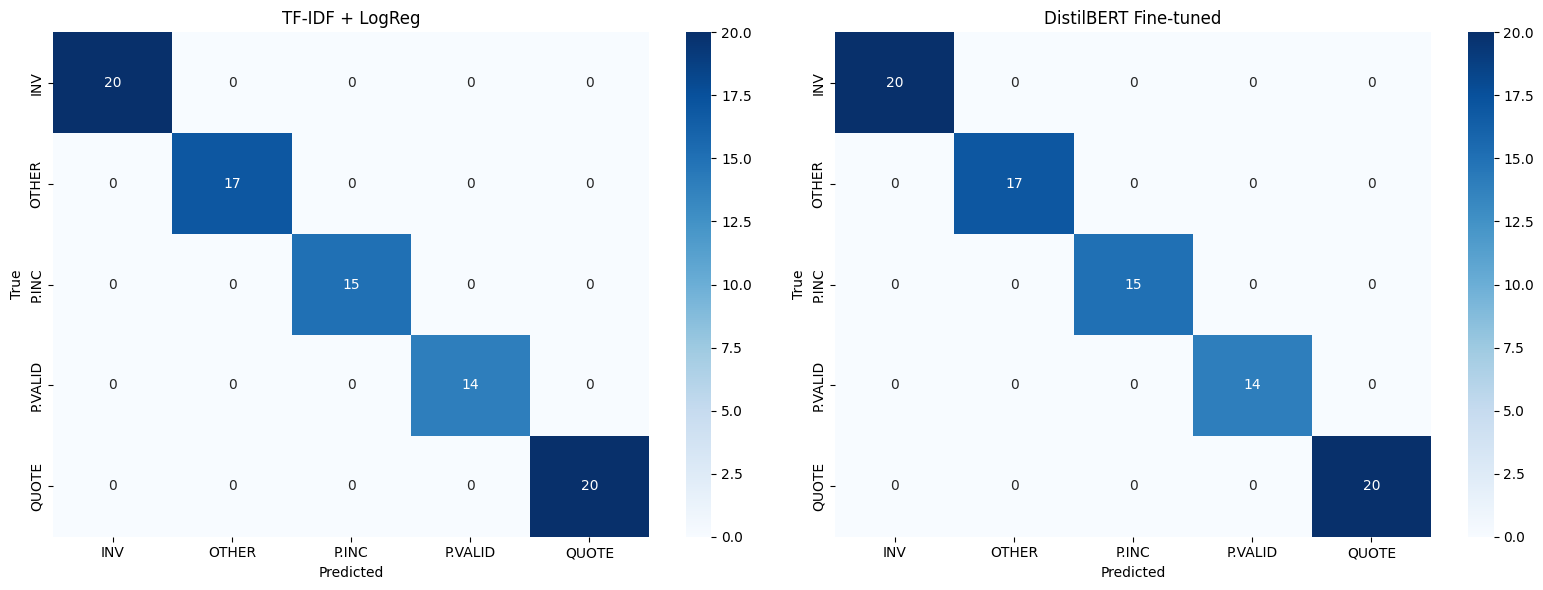

Saved: confusion_matrices.png


In [12]:
# 8. Confusion matrix visualization
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

short_labels = ['INV', 'OTHER', 'P.INC', 'P.VALID', 'QUOTE']

for ax, preds, title in [
    (axes[0], baseline_preds, 'TF-IDF + LogReg'),
    (axes[1], bert_preds, 'DistilBERT Fine-tuned'),
]:
    cm = confusion_matrix(test_labels, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=short_labels, yticklabels=short_labels, ax=ax)
    ax.set_title(title)
    ax.set_ylabel('True')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrices.png')

In [13]:
# 9. COMPARISON SUMMARY
print('=' * 55)
print(f'{"Method":<30s} {"Accuracy":>10s} {"F1 (macro)":>12s}')
print('-' * 55)
print(f'{"TF-IDF + LogReg":<30s} {baseline_acc:>10.4f} {baseline_f1:>12.4f}')
print(f'{"DistilBERT fine-tuned":<30s} {bert_acc:>10.4f} {bert_f1:>12.4f}')
print('=' * 55)

# Save results
results = {
    'baseline': {'accuracy': float(baseline_acc), 'f1_macro': float(baseline_f1)},
    'distilbert': {'accuracy': float(bert_acc), 'f1_macro': float(bert_f1)},
}
with open('intent_results.json', 'w') as f:
    json.dump(results, f, indent=2)
print('\nSaved: intent_results.json')

Method                           Accuracy   F1 (macro)
-------------------------------------------------------
TF-IDF + LogReg                    1.0000       1.0000
DistilBERT fine-tuned              1.0000       1.0000

Saved: intent_results.json


In [14]:
# 10. Save model for later use
trainer.save_model('./intent_model/best_model')
tokenizer.save_pretrained('./intent_model/best_model')

# Download results
from google.colab import files
files.download('intent_results.json')
files.download('confusion_matrices.png')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## Evaluare pe date augmentate (Text Augmentation)

Antrenam clasificatorii pe date curate + text augmentat, testam pe text augmentat.
Asta demonstreaza ca 100% pe date curate era datorat template-urilor controlate.

In [15]:
# 11. Upload augmented train + test CSVs
# Run locally first:
#   python augmentation.py --scenario text --severity medium --split train
#   python augmentation.py --scenario text --severity medium --split test
from google.colab import files
import os, csv

print('Upload from augmented/ folder:')
print('  train_text_medium.csv')
print('  test_text_medium.csv')
uploaded_aug = files.upload()

for f in ['train_text_medium.csv', 'test_text_medium.csv']:
    print(f'  {"OK" if os.path.exists(f) else "MISSING"}: {f}')

Upload from augmented/ folder:
  train_text_medium.csv
  test_text_medium.csv


Saving test_text_medium.csv to test_text_medium.csv
Saving train_text_medium.csv to train_text_medium.csv
  OK: train_text_medium.csv
  OK: test_text_medium.csv


In [16]:
# 12. Load and combine training data (clean + augmented)
def load_aug(path):
    records = []
    with open(path, 'r', encoding='utf-8-sig') as f:
        for row in csv.DictReader(f):
            records.append(row)
    return records

aug_train = load_aug('train_text_medium.csv')
aug_test = load_aug('test_text_medium.csv')

# Combine clean + augmented train
aug_train_texts = [f"Subject: {r['subject']}\n\n{r['body']}" for r in aug_train]
aug_train_labels = [LABEL2ID[r['intent']] for r in aug_train]

combined_texts = train_texts + aug_train_texts
combined_labels = train_labels + aug_train_labels

print(f'Clean train: {len(train_texts)} examples')
print(f'Aug train:   {len(aug_train_texts)} examples')
print(f'Combined:    {len(combined_texts)} examples')
print(f'Aug test:    {len(aug_test)} examples')

Clean train: 345 examples
Aug train:   345 examples
Combined:    690 examples
Aug test:    86 examples


In [17]:
# 13. Re-train TF-IDF on combined data and evaluate
from sklearn.pipeline import Pipeline as SkPipeline

# Re-train baseline
baseline_aug = SkPipeline([
    ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1, 2), sublinear_tf=True)),
    ('clf', LogisticRegression(max_iter=1000, C=1.0, class_weight='balanced', random_state=42)),
])
baseline_aug.fit(combined_texts, combined_labels)

# Evaluate on augmented test
aug_test_texts = [f"Subject: {r['subject']}\n\n{r['body']}" for r in aug_test]
aug_test_labels = [LABEL2ID[r['intent']] for r in aug_test]

bl_aug_preds = baseline_aug.predict(aug_test_texts)
bl_aug_acc = accuracy_score(aug_test_labels, bl_aug_preds)
bl_aug_f1 = f1_score(aug_test_labels, bl_aug_preds, average='macro')

print(f'TF-IDF on augmented test:')
print(f'  Accuracy: {bl_aug_acc:.4f}  F1 macro: {bl_aug_f1:.4f}')
print()
print(classification_report(aug_test_labels, bl_aug_preds,
      target_names=INTENT_LABELS, digits=4))

TF-IDF on augmented test:
  Accuracy: 0.9884  F1 macro: 0.9882

                             precision    recall  f1-score   support

         invoice_submission     0.9524    1.0000    0.9756        20
                      other     1.0000    1.0000    1.0000        17
             price_increase     1.0000    0.9333    0.9655        15
price_validity_confirmation     1.0000    1.0000    1.0000        14
                quote_offer     1.0000    1.0000    1.0000        20

                   accuracy                         0.9884        86
                  macro avg     0.9905    0.9867    0.9882        86
               weighted avg     0.9889    0.9884    0.9883        86



In [19]:
# 14. Re-train DistilBERT on combined data
# Create combined datasets (folosind aceeasi functie make_dataset ca la antrenamentul initial)
combined_ds = make_dataset(combined_texts, combined_labels)
aug_test_ds = make_dataset(aug_test_texts, aug_test_labels)

print(f'Combined train dataset: {len(combined_ds)} examples')
print(f'Augmented test dataset: {len(aug_test_ds)} examples')

# Re-initialize model (fresh weights)
from transformers import AutoModelForSequenceClassification

model_aug = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(INTENT_LABELS),
    id2label=ID2LABEL,
    label2id=LABEL2ID,
).to('cuda' if torch.cuda.is_available() else 'cpu')

# New trainer
from transformers import TrainingArguments, Trainer

aug_training_args = TrainingArguments(
    output_dir='./intent_aug_model',
    num_train_epochs=10,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    greater_is_better=True,
    logging_steps=20,
    save_total_limit=2,
    report_to='none',
    seed=42,
)

trainer_aug = Trainer(
    model=model_aug,
    args=aug_training_args,
    train_dataset=combined_ds,
    eval_dataset=aug_test_ds,
    compute_metrics=compute_metrics,
)

print('Training DistilBERT on combined (clean + augmented) data...')
trainer_aug.train()
print('Training complete!')

Map:   0%|          | 0/690 [00:00<?, ? examples/s]

Map:   0%|          | 0/86 [00:00<?, ? examples/s]

Combined train dataset: 690 examples
Augmented test dataset: 86 examples


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Training complete!


In [20]:
# 15. Evaluate DistilBERT on augmented test
bert_aug_output = trainer_aug.predict(aug_test_ds)
bert_aug_preds = np.argmax(bert_aug_output.predictions, axis=-1)
bert_aug_acc = accuracy_score(aug_test_labels, bert_aug_preds)
bert_aug_f1 = f1_score(aug_test_labels, bert_aug_preds, average='macro')

print(f'DistilBERT on augmented test:')
print(f'  Accuracy: {bert_aug_acc:.4f}  F1 macro: {bert_aug_f1:.4f}')
print()
print(classification_report(aug_test_labels, bert_aug_preds,
      target_names=INTENT_LABELS, digits=4))

DistilBERT on augmented test:
  Accuracy: 1.0000  F1 macro: 1.0000

                             precision    recall  f1-score   support

         invoice_submission     1.0000    1.0000    1.0000        20
                      other     1.0000    1.0000    1.0000        17
             price_increase     1.0000    1.0000    1.0000        15
price_validity_confirmation     1.0000    1.0000    1.0000        14
                quote_offer     1.0000    1.0000    1.0000        20

                   accuracy                         1.0000        86
                  macro avg     1.0000    1.0000    1.0000        86
               weighted avg     1.0000    1.0000    1.0000        86



Method                        Clean F1 Augmented F1     Drop
------------------------------------------------------------
TF-IDF + LogReg                100.00%       98.82%     1.2pp
DistilBERT                     100.00%      100.00%     0.0pp


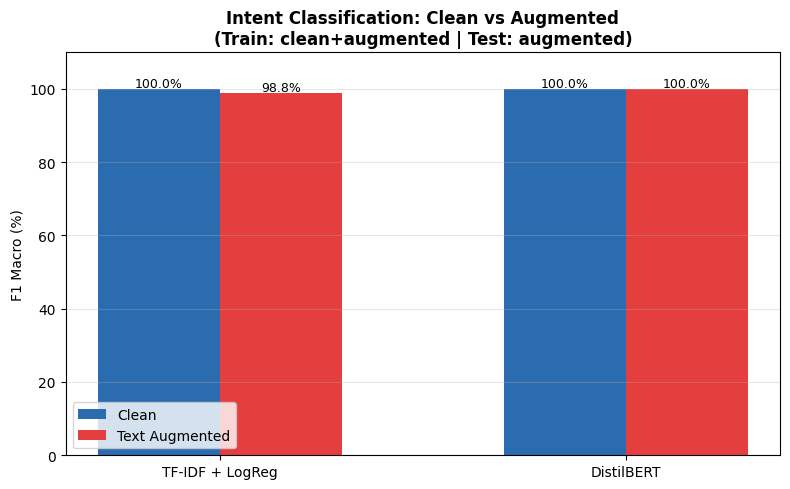

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [21]:
# 16. Comparison: clean vs augmented
import matplotlib.pyplot as plt

# Get clean DistilBERT F1
bert_clean_preds = np.argmax(predictions.predictions, axis=-1)
bert_clean_f1 = f1_score(test_labels, bert_clean_preds, average='macro')

print('=' * 60)
print(f'{"Method":<25s} {"Clean F1":>12s} {"Augmented F1":>12s} {"Drop":>8s}')
print('-' * 60)
print(f'{"TF-IDF + LogReg":<25s} {baseline_f1*100:>11.2f}% {bl_aug_f1*100:>11.2f}% '
      f'{(baseline_f1-bl_aug_f1)*100:>7.1f}pp')
print(f'{"DistilBERT":<25s} {bert_clean_f1*100:>11.2f}% {bert_aug_f1*100:>11.2f}% '
      f'{(bert_clean_f1-bert_aug_f1)*100:>7.1f}pp')
print('=' * 60)

# Bar chart
methods = ['TF-IDF + LogReg', 'DistilBERT']
clean_vals = [baseline_f1 * 100, bert_clean_f1 * 100]
aug_vals = [bl_aug_f1 * 100, bert_aug_f1 * 100]

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(methods))
ax.bar(x - 0.15, clean_vals, 0.3, label='Clean', color='#2b6cb0')
ax.bar(x + 0.15, aug_vals, 0.3, label='Text Augmented', color='#e53e3e')
for i, (c, a) in enumerate(zip(clean_vals, aug_vals)):
    ax.text(i - 0.15, c + 0.5, f'{c:.1f}%', ha='center', fontsize=9)
    ax.text(i + 0.15, a + 0.5, f'{a:.1f}%', ha='center', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.set_ylabel('F1 Macro (%)')
ax.set_title('Intent Classification: Clean vs Augmented\n'
             '(Train: clean+augmented | Test: augmented)', fontweight='bold')
ax.legend()
ax.set_ylim(0, 110)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('intent_clean_vs_augmented.png', dpi=200, bbox_inches='tight')
plt.show()
files.download('intent_clean_vs_augmented.png')